In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.io import fits
from astropy.table import Table

def match_catalog(file_name, gal_coords, hdu=0, url=None, dbx=None):
    if url is None: # get images locally
        with fits.open(file_name) as hdul:
            image_header = hdul[hdu].header
            image_data = hdul[hdu].data
    else: # Get FITS file from dropbox
        image_header, image_data = get_fits_file(url, file_name, dbx=dbx)
    
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

# HUDF first:

In [48]:
candels_cat_file = '../catalog/gds.fits'
other_candels_cat_file = '../catalog/hlsp_candels_hst_wfc3_goodss-tot-multiband_f160w_v1_cat.fits'

jwst_files = glob.glob("../data/JWST/HUDF/*")
nisp_files = glob.glob("../data/NISP-Y/HUDF/*")

In [50]:
tbl = Table.read(candels_cat_file).to_pandas()
tbl['ACS_F814W_MAG'] = 23.9-2.5*np.log10(tbl.ACS_F814W_FLUX)
tbl = tbl[
        (tbl.z_best > 0.01) & (tbl.z_best < 3.0)
        & (tbl.ACS_F814W_MAG < 25)
        & (tbl.CLASS_STAR < 0.05)
]

gal_coords = SkyCoord(tbl.RAdeg, tbl.DECdeg, unit='deg')

with fits.open(jwst_files[0]) as hdul:
    print(hdul.info())
    jwst_hdr = hdul[1].header
    jwst_data = hdul[1].data
wcs = WCS(jwst_hdr)
gal_coords = gal_coords[np.where(gal_coords.contained_by(wcs))[0]]

with fits.open(nisp_files[0]) as hdul:
    print(hdul.info())
    nisp_hdr = hdul[0].header
    nisp_data = hdul[0].data
wcs2 = WCS(nisp_hdr)

Filename: ../data/JWST/HUDF/hlsp_jades_jwst_nircam_goods-s-deep_f115w_v2.0_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     442   ()      
  1  SCI           1 ImageHDU        83   (25000, 27700)   float32   
  2  ERR           1 ImageHDU        83   (25000, 27700)   float32   
  3  EXP           1 ImageHDU        83   (25000, 27700)   float32   
  4  WHT           1 ImageHDU        83   (25000, 27700)   float32   
None
Filename: ../data/NISP-Y/HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102044825-5E4CFE_20241021T025742.150517Z_00.00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   (19200, 19200)   float32   
None


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
Set DATE-AVG to '2022-10-08T02:26:24.819' from MJD-AVG.
Set DATE-END to '2022-10-09T02:34:11.369' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    22.090597 from OBSGEO-[XYZ].
Set OBSGEO-H to 1234812278.786 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


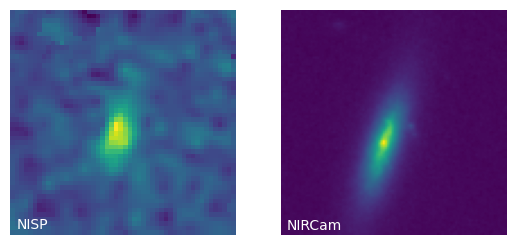

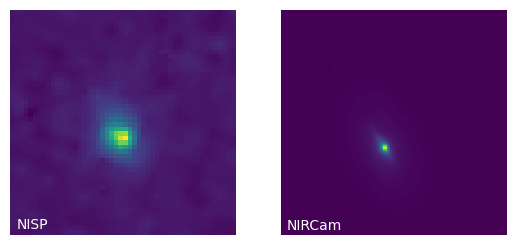

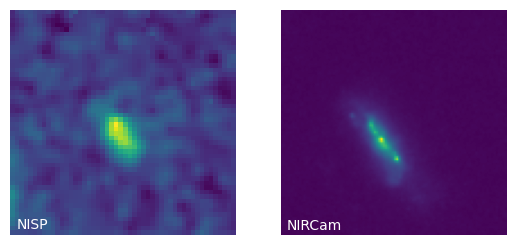

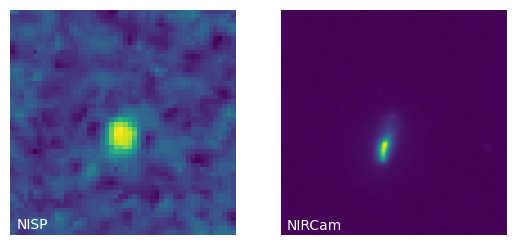

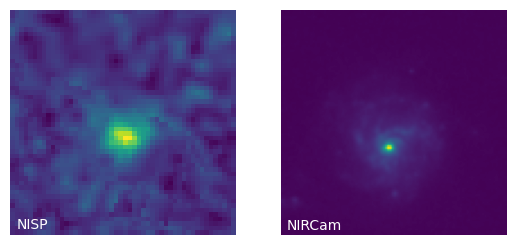

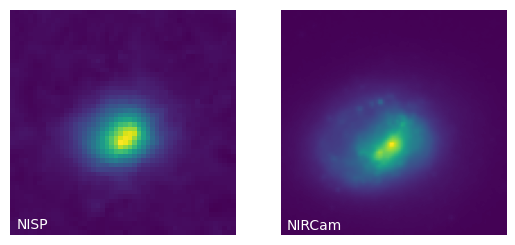

In [73]:
counter=0
for i in range(200):
    coords = gal_coords[np.random.randint(len(gal_coords))]
    clip = Cutout2D(jwst_data, coords, size=104, wcs=wcs)
    
    if np.sum(clip.data)!=0 and counter<50:
        try:
            clip_euc = Cutout2D(nisp_data, coords, size=50, wcs=wcs2)
            plt.subplot(1,2,2)
            plt.imshow(clip.data[2:-2,4:],origin='lower')
            plt.text(2,2,'NIRCam',color='w')
            plt.axis('off')
            plt.subplot(1,2,1)
            plt.imshow(clip_euc.data,origin='lower')
            plt.text(1,1,'NISP',color='w')
            plt.axis('off')
            plt.show()
            counter+=1
        except:
            pass
        

# Cosmos

In [25]:
cosmos_cat_file = '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits'

jwst_files = glob.glob("../data/JWST/cosmos/*")
nisp_files = glob.glob("../data/NISP-Y/cosmos/*")

In [40]:
tbl = Table.read(cosmos_cat_file).to_pandas()
tbl['ACS_F814W_MAG'] = 23.9-2.5*np.log10(tbl.ACS_F814W_FLUX)
tbl = tbl[
        (tbl.lp_zBEST > 0.01) & (tbl.lp_zBEST < 3.0)
        & (tbl.ACS_F814W_MAG < 25)
]

gal_coords = SkyCoord(tbl.ALPHA_J2000, tbl.DELTA_J2000, unit='deg')



Filename: ../data/JWST/cosmos/mosaic_nircam_f115w_COSMOS-Web_60mas_A1_v0_8_sci.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      73   (9600, 12455)   float32   
None
Filename: ../data/NISP-Y/cosmos/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE101544255-620AEC_20240805T220155.902495Z_00.00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   (10200, 10200)   float32   
None


Set DATE-AVG to '2023-06-16T05:08:56.131' from MJD-AVG.
Set DATE-END to '2024-04-23T13:30:58.404' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -14.819600 from OBSGEO-[XYZ].
Set OBSGEO-H to 1446438097.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
